<a href="https://colab.research.google.com/github/biopharma26/PracticeNotebooks/blob/main/4_2_Alignment_Assembly.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Lab 2: Read Alignment (BWA vs. Bowtie2) and Genome Assembly Strategies

**Estimated time:** 90–120 minutes  **Prerequisites:** completion of Lab 1 (concepts only — no files carry over).

### Learning Objectives
- Compare the design and appropriate use cases of BWA and Bowtie2.
- Align a simulated set of reads to a reference genome with both tools and compare the outputs.
- Explain, with a worked example, the difference between Overlap-Layout-Consensus (OLC) and de Bruijn graph (dBG) assembly.
- Justify the choice of an alignment tool or assembly strategy for a given sequencing experiment.

> This notebook builds its own miniature reference genome and simulated reads, so it runs standalone. Run cells top to bottom.

## Setup

In [1]:
%%capture
!apt-get -qq update
!apt-get -qq install -y bwa bowtie2 samtools > /dev/null
!pip -q install biopython networkx matplotlib

## Background

BWA and Bowtie2 both use the Burrows-Wheeler Transform and an FM-index to align short reads efficiently to a reference genome, but they are tuned for different scenarios: **BWA-MEM** handles longer short-reads and structural variants well, while **Bowtie2** is fast and memory-efficient and is commonly used for RNA-Seq and ChIP-Seq. When no reference genome exists, *de novo* assembly is required. **Overlap-Layout-Consensus (OLC)** finds pairwise overlaps between reads, builds an overlap graph, and derives a consensus — well suited to long reads (PacBio, Oxford Nanopore) despite high computational cost. **De Bruijn graph (dBG)** assembly instead breaks reads into fixed-length k-mers and resolves the sequence via an Eulerian path, scaling efficiently to the billions of short Illumina reads.

## Part A — Building a Reference and Simulating Reads
We generate a random 5,000 bp reference (a stand-in for a real chromosome) and simulate 100 bp single-end reads from it with a small sequencing-error rate, so the *true* alignment for every read is known — useful for checking your work.

In [2]:
import random
random.seed(7)

BASES = "ACGT"
GENOME_LEN = 5000
N_READS = 800
READ_LEN = 100
ERROR_RATE = 0.01  # 1% per-base sequencing error, roughly Illumina-like

reference = "".join(random.choice(BASES) for _ in range(GENOME_LEN))
with open("reference.fasta", "w") as f:
    f.write(">chrSim\n")
    for i in range(0, len(reference), 70):
        f.write(reference[i:i + 70] + "\n")

print(f"Simulated a {GENOME_LEN} bp reference: reference.fasta")


Simulated a 5000 bp reference: reference.fasta


In [3]:
def mutate(seq, error_rate):
    bases = list(seq)
    for i in range(len(bases)):
        if random.random() < error_rate:
            bases[i] = random.choice([b for b in BASES if b != bases[i]])
    return "".join(bases)

def phred_string(length, mean_q=35):
    return "".join(chr(min(max(mean_q + random.randint(-3, 3), 2), 40) + 33) for _ in range(length))

reads = []
true_positions = []
for i in range(N_READS):
    start = random.randint(0, GENOME_LEN - READ_LEN)
    true_positions.append(start + 1)  # 1-based, for later comparison
    read_seq = mutate(reference[start:start + READ_LEN], ERROR_RATE)
    reads.append((f"sim_read_{i}", read_seq, phred_string(READ_LEN)))

with open("reads.fastq", "w") as f:
    for name, seq, qual in reads:
        f.write(f"@{name}\n{seq}\n+\n{qual}\n")

print(f"Simulated {len(reads)} reads of length {READ_LEN} -> reads.fastq")


Simulated 800 reads of length 100 -> reads.fastq


### Align with BWA-MEM

In [4]:
!bwa index reference.fasta
!bwa mem reference.fasta reads.fastq > aln_bwa.sam 2> bwa.log
!samtools sort aln_bwa.sam -o aln_bwa.sorted.bam
!samtools index aln_bwa.sorted.bam
!samtools flagstat aln_bwa.sorted.bam


[bwa_index] Pack FASTA... 0.00 sec
[bwa_index] Construct BWT for the packed sequence...
[bwa_index] 0.00 seconds elapse.
[bwa_index] Update BWT... 0.00 sec
[bwa_index] Pack forward-only FASTA... 0.00 sec
[bwa_index] Construct SA from BWT and Occ... 0.00 sec
[main] Version: 0.7.17-r1188
[main] CMD: bwa index reference.fasta
[main] Real time: 0.043 sec; CPU: 0.005 sec
800 + 0 in total (QC-passed reads + QC-failed reads)
800 + 0 primary
0 + 0 secondary
0 + 0 supplementary
0 + 0 duplicates
0 + 0 primary duplicates
800 + 0 mapped (100.00% : N/A)
800 + 0 primary mapped (100.00% : N/A)
0 + 0 paired in sequencing
0 + 0 read1
0 + 0 read2
0 + 0 properly paired (N/A : N/A)
0 + 0 with itself and mate mapped
0 + 0 singletons (N/A : N/A)
0 + 0 with mate mapped to a different chr
0 + 0 with mate mapped to a different chr (mapQ>=5)


### Align with Bowtie2

In [5]:
!bowtie2-build -q reference.fasta reference_bt2
!bowtie2 -x reference_bt2 -U reads.fastq -S aln_bt2.sam 2> bowtie2.log
!samtools sort aln_bt2.sam -o aln_bt2.sorted.bam
!samtools index aln_bt2.sorted.bam
!samtools flagstat aln_bt2.sorted.bam


800 + 0 in total (QC-passed reads + QC-failed reads)
800 + 0 primary
0 + 0 secondary
0 + 0 supplementary
0 + 0 duplicates
0 + 0 primary duplicates
800 + 0 mapped (100.00% : N/A)
800 + 0 primary mapped (100.00% : N/A)
0 + 0 paired in sequencing
0 + 0 read1
0 + 0 read2
0 + 0 properly paired (N/A : N/A)
0 + 0 with itself and mate mapped
0 + 0 singletons (N/A : N/A)
0 + 0 with mate mapped to a different chr
0 + 0 with mate mapped to a different chr (mapQ>=5)


In [6]:
!cat bowtie2.log


800 reads; of these:
  800 (100.00%) were unpaired; of these:
    0 (0.00%) aligned 0 times
    800 (100.00%) aligned exactly 1 time
    0 (0.00%) aligned >1 times
100.00% overall alignment rate


### Check Alignment Accuracy
Because we know the *true* origin of every simulated read, we can directly check how many reads each tool placed at (or very near) their true position.

In [9]:
!pip install pysam
import pysam

def accuracy(bam_path, true_pos_by_name, tolerance=2):
    bam = pysam.AlignmentFile(bam_path, "rb")
    correct = 0
    mapped = 0
    for read in bam:
        if read.is_unmapped:
            continue
        mapped += 1
        true_pos = true_pos_by_name[read.query_name]
        if abs((read.reference_start + 1) - true_pos) <= tolerance:
            correct += 1
    bam.close()
    return mapped, correct

true_pos_by_name = {f"sim_read_{i}": pos for i, pos in enumerate(true_positions)}

for label, bam_path in [("BWA-MEM", "aln_bwa.sorted.bam"), ("Bowtie2", "aln_bt2.sorted.bam")]:
    mapped, correct = accuracy(bam_path, true_pos_by_name)
    print(f"{label:10s}: {mapped}/{N_READS} mapped, {correct}/{mapped} placed within 2 bp of the true origin")

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 25.6/25.6 MB 93.6 MB/s eta 0:00:00
BWA-MEM   : 800/800 mapped, 798/800 placed within 2 bp of the true origin
Bowtie2   : 800/800 mapped, 800/800 placed within 2 bp of the true origin


**Q1.** Compare the overall alignment rates reported by `samtools flagstat` for BWA-MEM and Bowtie2. Are they similar, given that both use the same underlying algorithm family?

_Your answer:_



**Q2.** Did either tool place a noticeably different number of reads at the wrong position? What might explain any difference you see?

_Your answer:_



## Part B — Comparing the Tools
Fill in the table below using your results above and the background material.

| Criterion | BWA | Bowtie2 |
|---|---|---|
| Core algorithm | | |
| Typical use case | | |
| Handling of indels / gapped alignment | | |
| Alignment rate observed in this lab | | |
| Reads correctly placed (this lab) | | |


## Part C — Assembly Strategy Worked Example

Consider the following three short reads (ignore sequencing errors for this exercise):

```
Read 1: ATGGCTA
Read 2: GCTACGT
Read 3: ACGTTAG
```

In [10]:
reads_c = ["ATGGCTA", "GCTACGT", "ACGTTAG"]


### OLC-style reconstruction
Find the overlap between the end of one read and the start of another, then greedily merge.

In [11]:
from itertools import permutations

def overlap(a, b, min_len=1):
    # Length of the longest suffix of a matching a prefix of b.
    start = 0
    while True:
        start = a.find(b[:min_len], start)
        if start == -1:
            return 0
        if b.startswith(a[start:]):
            return len(a) - start
        start += 1

def shortest_superstring(reads):
    best = None
    for perm in permutations(reads):
        s = perm[0]
        for r in perm[1:]:
            ov = overlap(s, r, 1)
            s += r[ov:]
        if best is None or len(s) < len(best):
            best = s
    return best

consensus = shortest_superstring(reads_c)
print("OLC consensus:", consensus)


OLC consensus: ATGGCTACGTTAG


**Q3.** By hand, show the pairwise overlaps you found between the three reads. Do they match what the code above computed?

_Your answer:_



### de Bruijn graph (dBG) reconstruction
Break each read into k-mers of length k = 5, build the graph, and find the Eulerian path. (k = 5 is chosen deliberately here: with these particular reads, k = 4 produces repeated k-mers at the overlap boundary that break the simple Eulerian-path property — a good illustration of how repeats can complicate real dBG assembly.)

In [12]:
import networkx as nx

K = 5

def kmers(seq, k):
    return [seq[i:i + k] for i in range(len(seq) - k + 1)]

all_kmers = []
for r in reads_c:
    all_kmers += kmers(r, K)

print("k-mers:", all_kmers)

G = nx.MultiDiGraph()
for km in all_kmers:
    G.add_edge(km[:-1], km[1:], label=km)

euler_path = list(nx.eulerian_path(G))
print("Eulerian path (edges):", euler_path)

reconstructed = euler_path[0][0]
for u, v in euler_path:
    reconstructed += v[-1]
print("dBG-reconstructed sequence:", reconstructed)


k-mers: ['ATGGC', 'TGGCT', 'GGCTA', 'GCTAC', 'CTACG', 'TACGT', 'ACGTT', 'CGTTA', 'GTTAG']
Eulerian path (edges): [('ATGG', 'TGGC'), ('TGGC', 'GGCT'), ('GGCT', 'GCTA'), ('GCTA', 'CTAC'), ('CTAC', 'TACG'), ('TACG', 'ACGT'), ('ACGT', 'CGTT'), ('CGTT', 'GTTA'), ('GTTA', 'TTAG')]
dBG-reconstructed sequence: ATGGCTACGTTAG


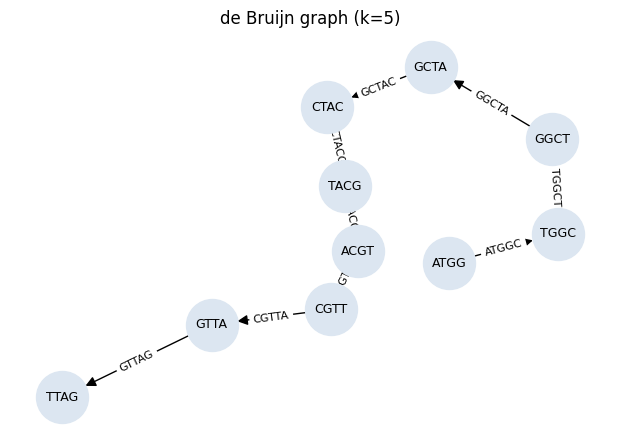

In [13]:
import matplotlib.pyplot as plt

plt.figure(figsize=(6, 4))
pos = nx.spring_layout(G, seed=1)
nx.draw(G, pos, with_labels=True, node_color="#DCE6F1", node_size=1400, font_size=9, arrowsize=15)
edge_labels = nx.get_edge_attributes(G, "label")
nx.draw_networkx_edge_labels(G, pos, edge_labels={k: v for k, v in list(edge_labels.items())[:len(all_kmers)]}, font_size=8)
plt.title("de Bruijn graph (k=5)")
plt.axis("off")
plt.show()


**Q4.** Does the dBG-reconstructed sequence match the OLC consensus? Should it, in principle?

_Your answer:_



**Try it:** change `K = 5` to `K = 4` above and re-run the two cells. You'll find `nx.eulerian_path` raises an error instead of returning a path.

**Q4b.** Investigate why k = 4 fails here (hint: print each node's in-degree and out-degree with `G.in_degree()` / `G.out_degree()`). What does this tell you about how repeated k-mers can complicate real genome assembly?

_Your answer:_



**Q5.** For a real Illumina whole-genome sequencing project generating hundreds of millions of short reads, explain why dBG assembly is preferred over OLC.

_Your answer:_



**Q6.** For a long-read Oxford Nanopore sequencing project, explain why OLC becomes practical again despite its computational cost.

_Your answer:_



## Discussion Questions

**Q7.** A colleague is designing an RNA-Seq experiment and asks whether to use BWA or Bowtie2. What would you recommend, and why?

_Your answer:_



**Q8.** What genome features (e.g., repeats) make de novo assembly harder regardless of the strategy chosen? How would that show up as a problem in the de Bruijn graph above (think about repeated k-mers)?

_Your answer:_



**Q9.** How does read length influence the choice between OLC and dBG approaches?

_Your answer:_



---
### Deliverable
The completed comparison table, the printed alignment-accuracy summary, the de Bruijn graph figure, and your written answers to Parts A–C and the discussion questions.